# Lab 4 — Submission Setup, and Object Oriented Programming

**This session (Friday 9/11) starts with getting submission working**, then moves to the
exercises.

Two halves:

1. **Setting up submission** — fork, clone, wire the remotes, commit, push. We do this together,
   from scratch. You do not need to have done anything beforehand. **Lab 2 is due tonight and you
   will submit it here.**
2. **The Object Oriented Programming exercises** — the lab itself, which uses the Lectures 8–9
   material.

`Labs/GitHub-Setup.pdf` is the written version of part 1, with a table of what to do when git
complains. If you already have authentication working from Lab 3, part 1 will be quick.


1. Write a "counter" class that can be incremented up to a specified maximum value, will print an error if an attempt is made to increment beyond that value, and allows reseting the counter. 

In [2]:
class Counter:
    def __init__(self, maximum):
        self.value = 0
        self.maximum = maximum

    def increment(self):
        if self.value < self.maximum:
            self.value += 1
        else:
            print("Error: counter is already at the maximum value.")

    def reset(self):
        self.value = 0

counter = Counter(3)
counter.increment()
counter.increment()
counter.increment()
counter.increment()  
print(counter.value)
counter.reset()
print(counter.value)


Error: counter is already at the maximum value.
3
0


2. Copy and paste your solution to question 1 and modify it so that all the data held by the counter is private. Implement functions to check the value of the counter, check the maximum value, and check if the counter is at the maximum.

In [3]:
class PrivateCounter:
    def __init__(self, maximum):
        self.__value = 0
        self.__maximum = maximum

    def increment(self):
        if self.__value < self.__maximum:
            self.__value += 1
        else:
            print("Error: counter is already at the maximum value.")

    def reset(self):
        self.__value = 0

    def get_value(self):
        return self.__value

    def get_maximum(self):
        return self.__maximum

    def at_maximum(self):
        return self.__value == self.__maximum


counter = PrivateCounter(3)
print(counter.get_value(), counter.get_maximum(), counter.at_maximum())
counter.increment()
counter.increment()
counter.increment()
print(counter.get_value(), counter.at_maximum())


0 3 False
3 True


3. Implement a class to represent a rectangle, holding the length, width, and $x$ and $y$ coordinates of a corner of the object. Implement functions that compute the area and perimeter of the rectangle. Make all data members private and provide accessors to retrieve values of data members. 

In [4]:
class Rectangle:
    def __init__(self, length, width, x, y):
        self.__length = length
        self.__width = width
        self.__x = x
        self.__y = y

    def get_length(self):
        return self.__length

    def get_width(self):
        return self.__width

    def get_x(self):
        return self.__x

    def get_y(self):
        return self.__y

    def area(self):
        return self.__length * self.__width

    def perimeter(self):
        return 2 * (self.__length + self.__width)

r = Rectangle(10, 4, 2, 3)
print("Area:", r.area())
print("Perimeter:", r.perimeter())
print("Length, width, x, y:", r.get_length(), r.get_width(), r.get_x(), r.get_y())


Area: 40
Perimeter: 28
Length, width, x, y: 10 4 2 3


4. Implement a class to represent a circle, holding the radius and $x$ and $y$ coordinates of center of the object. Implement functions that compute the area and perimeter of the circle. Make all data members private and provide accessors to retrieve values of data members. 

In [5]:
import math

class Circle:
    def __init__(self, radius, x, y):
        self.__radius = radius
        self.__x = x
        self.__y = y

    def get_radius(self):
        return self.__radius

    def get_x(self):
        return self.__x

    def get_y(self):
        return self.__y

    def area(self):
        return math.pi * self.__radius ** 2

    def perimeter(self):
        return 2 * math.pi * self.__radius

c = Circle(5, 2, 3)
print("Area:", c.area())
print("Perimeter:", c.perimeter())
print("Radius, x, y:", c.get_radius(), c.get_x(), c.get_y())


Area: 78.53981633974483
Perimeter: 31.41592653589793
Radius, x, y: 5 2 3


5. Implement a common base class for the classes implemented in 3 and 4 above which implements all common methods as not implemented functions (virtual). Re-implement your rectangle and circle classes to inherit from the base class and overload the functions accordingly. 

In [6]:
from abc import ABC, abstractmethod
import math

class Shape(ABC):
    @abstractmethod
    def area(self):
        pass

    @abstractmethod
    def perimeter(self):
        pass

    @abstractmethod
    def get_x(self):
        pass

    @abstractmethod
    def get_y(self):
        pass

    @abstractmethod
    def perimeter_points(self, n=16):
        pass

    @abstractmethod
    def contains(self, x, y):
        pass

    def overlaps(self, other):
        a = self.bounding_box()
        b = other.bounding_box()
        if a[2] < b[0] or b[2] < a[0] or a[3] < b[1] or b[3] < a[1]:
            return False

        for x, y in self.perimeter_points(16):
            if other.contains(x, y):
                return True
        for x, y in other.perimeter_points(16):
            if self.contains(x, y):
                return True

        if self.contains(other.get_x(), other.get_y()):
            return True
        if other.contains(self.get_x(), self.get_y()):
            return True
        return True

    @abstractmethod
    def bounding_box(self):
        pass

class Rectangle(Shape):
    def __init__(self, length, width, x, y):
        self.__length = length
        self.__width = width
        self.__x = x
        self.__y = y

    def get_length(self): return self.__length
    def get_width(self): return self.__width
    def get_x(self): return self.__x
    def get_y(self): return self.__y
    def area(self): return self.__length * self.__width
    def perimeter(self): return 2 * (self.__length + self.__width)

    def perimeter_points(self, n=16):
        n = max(4, min(16, n))
        counts = [n // 4] * 4
        for i in range(n % 4): counts[i] += 1
        pts=[]
        sides=[
            ((self.__x, self.__y), (self.__x+self.__length, self.__y)),
            ((self.__x+self.__length, self.__y), (self.__x+self.__length, self.__y+self.__width)),
            ((self.__x+self.__length, self.__y+self.__width), (self.__x, self.__y+self.__width)),
            ((self.__x, self.__y+self.__width), (self.__x, self.__y)),
        ]
        for (x1,y1),(x2,y2),count in zip([s[0] for s in sides],[s[1] for s in sides],counts):
            if count == 1:
                pts.append((x1,y1))
            else:
                for j in range(count):
                    t=j/count
                    pts.append((x1+t*(x2-x1), y1+t*(y2-y1)))
        return pts[:n]

    def contains(self, x, y):
        return self.__x <= x <= self.__x+self.__length and self.__y <= y <= self.__y+self.__width

    def bounding_box(self):
        return (self.__x, self.__y, self.__x+self.__length, self.__y+self.__width)

class Circle(Shape):
    def __init__(self, radius, x, y):
        self.__radius = radius
        self.__x = x
        self.__y = y

    def get_radius(self): return self.__radius
    def get_x(self): return self.__x
    def get_y(self): return self.__y
    def area(self): return math.pi * self.__radius**2
    def perimeter(self): return 2 * math.pi * self.__radius

    def perimeter_points(self, n=16):
        n = max(1, min(16, n))
        return [(self.__x+self.__radius*math.cos(2*math.pi*i/n),
                 self.__y+self.__radius*math.sin(2*math.pi*i/n)) for i in range(n)]

    def contains(self, x, y):
        return (x-self.__x)**2 + (y-self.__y)**2 <= self.__radius**2

    def bounding_box(self):
        return (self.__x-self.__radius, self.__y-self.__radius,
                self.__x+self.__radius, self.__y+self.__radius)

shapes = [Rectangle(4, 3, 0, 0), Circle(2, 5, 5)]
for shape in shapes:
    print(type(shape).__name__, "area =", shape.area(), "perimeter =", shape.perimeter())


Rectangle area = 12 perimeter = 14
Circle area = 12.566370614359172 perimeter = 12.566370614359172


6. Implement a triangle class analogous to the rectangle and circle in question 5.

In [7]:
class Triangle(Shape):
    def __init__(self, x1, y1, x2, y2, x3, y3):
        self.__x1, self.__y1 = x1, y1
        self.__x2, self.__y2 = x2, y2
        self.__x3, self.__y3 = x3, y3

    def get_x(self): return self.__x1
    def get_y(self): return self.__y1
    def get_x1(self): return self.__x1
    def get_y1(self): return self.__y1
    def get_x2(self): return self.__x2
    def get_y2(self): return self.__y2
    def get_x3(self): return self.__x3
    def get_y3(self): return self.__y3

    def _side_lengths(self):
        a = math.hypot(self.__x2-self.__x3, self.__y2-self.__y3)
        b = math.hypot(self.__x1-self.__x3, self.__y1-self.__y3)
        c = math.hypot(self.__x1-self.__x2, self.__y1-self.__y2)
        return a, b, c

    def perimeter(self):
        return sum(self._side_lengths())

    def area(self):
        return abs((self.__x1*(self.__y2-self.__y3) +
                    self.__x2*(self.__y3-self.__y1) +
                    self.__x3*(self.__y1-self.__y2)) / 2)

    def perimeter_points(self, n=16):
        n=max(3, min(16,n))
        vertices=[(self.__x1,self.__y1),(self.__x2,self.__y2),(self.__x3,self.__y3)]
        pts=[]
        counts=[n//3]*3
        for i in range(n%3): counts[i]+=1
        for i,count in enumerate(counts):
            p1=vertices[i]; p2=vertices[(i+1)%3]
            for j in range(count):
                t=j/count
                pts.append((p1[0]+t*(p2[0]-p1[0]), p1[1]+t*(p2[1]-p1[1])))
        return pts[:n]

    def contains(self, x, y):
        def sign(px,py, ax,ay,bx,by):
            return (px-bx)*(ay-by) - (ax-bx)*(py-by)
        d1=sign(x,y,self.__x1,self.__y1,self.__x2,self.__y2)
        d2=sign(x,y,self.__x2,self.__y2,self.__x3,self.__y3)
        d3=sign(x,y,self.__x3,self.__y3,self.__x1,self.__y1)
        has_neg=(d1<0) or (d2<0) or (d3<0)
        has_pos=(d1>0) or (d2>0) or (d3>0)
        return not (has_neg and has_pos)

    def bounding_box(self):
        return (min(self.__x1,self.__x2,self.__x3),
                min(self.__y1,self.__y2,self.__y3),
                max(self.__x1,self.__x2,self.__x3),
                max(self.__y1,self.__y2,self.__y3))

triangle = Triangle(0, 0, 4, 0, 0, 3)
print("Area:", triangle.area())
print("Perimeter:", triangle.perimeter())
print("Contains (1,1):", triangle.contains(1,1))


Area: 6.0
Perimeter: 12.0
Contains (1,1): True


7. Add a function to the object classes, including the base, that returns a list of up to 16 pairs of  $x$ and $y$ points on the perimeter of the object. 

In [8]:
rectangle = Rectangle(4, 2, 0, 0)
circle = Circle(3, 5, 5)
triangle = Triangle(0, 0, 4, 0, 2, 3)

print("Rectangle points:", rectangle.perimeter_points(16))
print("Circle points:", circle.perimeter_points(16))
print("Triangle points:", triangle.perimeter_points(16))


Rectangle points: [(0.0, 0.0), (1.0, 0.0), (2.0, 0.0), (3.0, 0.0), (4.0, 0.0), (4.0, 0.5), (4.0, 1.0), (4.0, 1.5), (4.0, 2.0), (3.0, 2.0), (2.0, 2.0), (1.0, 2.0), (0.0, 2.0), (0.0, 1.5), (0.0, 1.0), (0.0, 0.5)]
Circle points: [(8.0, 5.0), (7.77163859753386, 6.148050297095269), (7.121320343559643, 7.121320343559642), (6.14805029709527, 7.77163859753386), (5.0, 8.0), (3.8519497029047307, 7.77163859753386), (2.8786796564403576, 7.121320343559643), (2.22836140246614, 6.14805029709527), (2.0, 5.0), (2.2283614024661396, 3.851949702904731), (2.878679656440357, 2.8786796564403576), (3.851949702904729, 2.2283614024661405), (4.999999999999999, 2.0), (6.14805029709527, 2.22836140246614), (7.121320343559642, 2.878679656440357), (7.77163859753386, 3.851949702904729)]
Triangle points: [(0.0, 0.0), (0.6666666666666666, 0.0), (1.3333333333333333, 0.0), (2.0, 0.0), (2.6666666666666665, 0.0), (3.3333333333333335, 0.0), (4.0, 0.0), (3.6, 0.6000000000000001), (3.2, 1.2000000000000002), (2.8, 1.79999999999

8. Add a function to the object classes, including the base, that tests if a given set of $x$ and $y$ coordinates are inside of the object. You'll have to think through how to determine if a set of coordinates are inside an object for each object type.

In [9]:
print("Rectangle contains (2,1):", rectangle.contains(2,1))
print("Rectangle contains (6,4):", rectangle.contains(6,4))
print("Circle contains (5,5):", circle.contains(5,5))
print("Circle contains (10,5):", circle.contains(10,5))
print("Triangle contains (2,1):", triangle.contains(2,1))
print("Triangle contains (5,5):", triangle.contains(5,5))


Rectangle contains (2,1): True
Rectangle contains (6,4): False
Circle contains (5,5): True
Circle contains (10,5): False
Triangle contains (2,1): True
Triangle contains (5,5): False


9. Add a function in the base class of the object classes that returns true/false testing that the object overlaps with another object.

In [10]:
print("Rectangle / Circle overlap:", rectangle.overlaps(circle))
print("Rectangle / Triangle overlap:", rectangle.overlaps(triangle))
print("Circle / Triangle overlap:", circle.overlaps(triangle))

r1 = Rectangle(4, 4, 0, 0)
r2 = Rectangle(3, 3, 2, 2)
print("Overlapping rectangles:", r1.overlaps(r2))


Rectangle / Circle overlap: True
Rectangle / Triangle overlap: True
Circle / Triangle overlap: True
Overlapping rectangles: True


10. Copy the `Canvas` class from lecture into a python file creating a `paint` module. Copy your classes from above into the module and implement paint functions. Implement a `CompoundShape` class. Create a simple drawing demonstrating that all of your classes are working.

Matplotlib is building the font cache; this may take a moment.


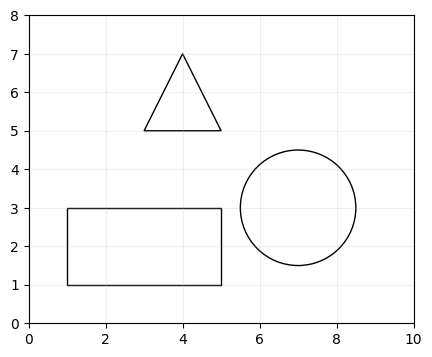

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as MplRectangle, Circle as MplCircle, Polygon as MplPolygon

class Canvas:
    def __init__(self, width=12, height=8):
        self.width = width
        self.height = height
        self.fig, self.ax = plt.subplots(figsize=(width/2, height/2))
        self.ax.set_aspect('equal')
        self.ax.set_xlim(0, width)
        self.ax.set_ylim(0, height)
        self.ax.grid(True, alpha=0.2)

    def rectangle(self, x, y, width, height):
        self.ax.add_patch(MplRectangle((x,y), width, height, fill=False))

    def circle(self, x, y, radius):
        self.ax.add_patch(MplCircle((x,y), radius, fill=False))

    def polygon(self, points):
        self.ax.add_patch(MplPolygon(points, closed=True, fill=False))

    def show(self):
        plt.show()


def paint(shape, canvas):
    if isinstance(shape, Rectangle):
        canvas.rectangle(shape.get_x(), shape.get_y(), shape.get_length(), shape.get_width())
    elif isinstance(shape, Circle):
        canvas.circle(shape.get_x(), shape.get_y(), shape.get_radius())
    elif isinstance(shape, Triangle):
        canvas.polygon([(shape.get_x1(),shape.get_y1()),
                        (shape.get_x2(),shape.get_y2()),
                        (shape.get_x3(),shape.get_y3())])
    elif isinstance(shape, CompoundShape):
        shape.paint(canvas)

class CompoundShape(Shape):
    def __init__(self, shapes=None):
        self.__shapes = list(shapes) if shapes else []

    def add(self, shape): self.__shapes.append(shape)
    def get_shapes(self): return list(self.__shapes)
    def get_x(self): return min(s.bounding_box()[0] for s in self.__shapes)
    def get_y(self): return min(s.bounding_box()[1] for s in self.__shapes)
    def area(self): return sum(s.area() for s in self.__shapes)
    def perimeter(self): return sum(s.perimeter() for s in self.__shapes)
    def perimeter_points(self, n=16):
        pts=[]
        for s in self.__shapes:
            pts.extend(s.perimeter_points(max(1, n//max(1,len(self.__shapes)))))
        return pts[:16]
    def contains(self, x, y): return any(s.contains(x,y) for s in self.__shapes)
    def bounding_box(self):
        boxes=[s.bounding_box() for s in self.__shapes]
        return (min(b[0] for b in boxes), min(b[1] for b in boxes),
                max(b[2] for b in boxes), max(b[3] for b in boxes))
    def paint(self, canvas):
        for s in self.__shapes:
            paint(s, canvas)

drawing = CompoundShape([
    Rectangle(4, 2, 1, 1),
    Circle(1.5, 7, 3),
    Triangle(3, 5, 5, 5, 4, 7)
])
canvas = Canvas(10, 8)
drawing.paint(canvas)
canvas.show()


11. Create a `RasterDrawing` class. Demonstrate that you can create a drawing made of several shapes, paint the drawing, modify the drawing, and paint it again. 

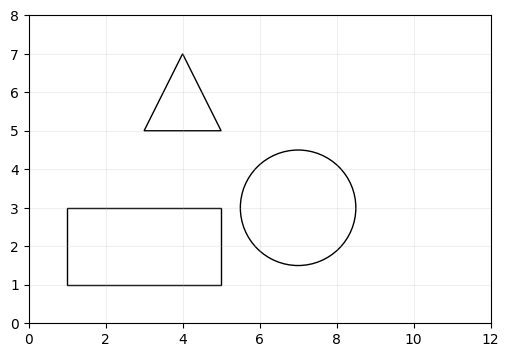

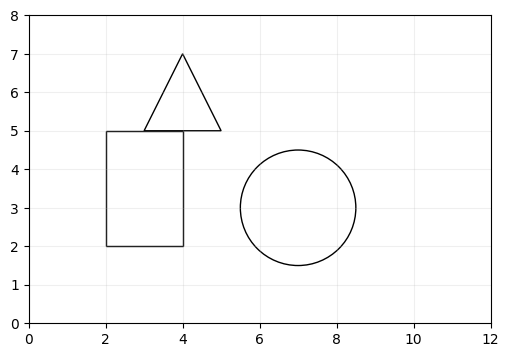

In [12]:
class RasterDrawing:
    def __init__(self, width=12, height=8, shapes=None):
        self.width = width
        self.height = height
        self.shapes = list(shapes) if shapes else []

    def add(self, shape):
        self.shapes.append(shape)

    def remove(self, shape):
        self.shapes.remove(shape)

    def paint(self):
        canvas = Canvas(self.width, self.height)
        for shape in self.shapes:
            paint(shape, canvas)
        canvas.show()

    def __repr__(self):
        return "RasterDrawing(" + repr(self.width) + ", " + repr(self.height) + ", " + repr(self.shapes) + ")"

raster = RasterDrawing(12, 8)
raster.add(Rectangle(4, 2, 1, 1))
raster.add(Circle(1.5, 7, 3))
raster.add(Triangle(3, 5, 5, 5, 4, 7))

raster.paint()

raster.remove(raster.shapes[0])
raster.add(Rectangle(2, 3, 2, 2))

raster.paint()


12. Implement the ability to load/save raster drawings and demonstrate that your method works. One way to implement this ability:

   * Overload `__repr__` functions of all objects to return strings of the python code that would construct the object.
   
   * In the save method of raster drawing class, store the representations into the file.
   * Write a loader function that reads the file and uses `eval` to instantiate the object.

For example:

In [13]:
def shape_repr(self):
    return repr(self)

def rectangle_repr(self):
    return f"Rectangle({self.get_length()!r}, {self.get_width()!r}, {self.get_x()!r}, {self.get_y()!r})"

def circle_repr(self):
    return f"Circle({self.get_radius()!r}, {self.get_x()!r}, {self.get_y()!r})"

def triangle_repr(self):
    return (f"Triangle({self.get_x1()!r}, {self.get_y1()!r}, "
            f"{self.get_x2()!r}, {self.get_y2()!r}, "
            f"{self.get_x3()!r}, {self.get_y3()!r})")

def compound_repr(self):
    return "CompoundShape(" + repr(self.get_shapes()) + ")"

def raster_repr(self):
    return f"RasterDrawing({self.width!r}, {self.height!r}, {self.shapes!r})"

Rectangle.__repr__ = rectangle_repr
Circle.__repr__ = circle_repr
Triangle.__repr__ = triangle_repr
CompoundShape.__repr__ = compound_repr
RasterDrawing.__repr__ = raster_repr

def save_drawing(drawing, filename):
    with open(filename, "w") as f:
        f.write(repr(drawing))

def load_drawing(filename):
    with open(filename, "r") as f:
        return eval(f.read(), {
            "RasterDrawing": RasterDrawing,
            "Rectangle": Rectangle,
            "Circle": Circle,
            "Triangle": Triangle,
            "CompoundShape": CompoundShape
        })

saved = RasterDrawing(10, 8, [Rectangle(3, 2, 1, 1), Circle(2, 6, 4), Triangle(2, 5, 4, 5, 3, 7)])
save_drawing(saved, "Test.RasterDrawing")
print("Saved representation:")
with open("Test.RasterDrawing") as f:
    print(f.read())

reloaded = load_drawing("Test.RasterDrawing")
print("Reloaded object:")
print(reloaded)


Saved representation:
RasterDrawing(10, 8, [Rectangle(3, 2, 1, 1), Circle(2, 6, 4), Triangle(2, 5, 4, 5, 3, 7)])
Reloaded object:
RasterDrawing(10, 8, [Rectangle(3, 2, 1, 1), Circle(2, 6, 4), Triangle(2, 5, 4, 5, 3, 7)])


In [14]:
print(repr(Rectangle(3, 2, 1, 1)))
print(repr(Circle(2, 6, 4)))
print(repr(Triangle(2, 5, 4, 5, 3, 7)))


Rectangle(3, 2, 1, 1)
Circle(2, 6, 4)
Triangle(2, 5, 4, 5, 3, 7)


In [15]:
ff = RasterDrawing(10, 8, [Rectangle(3, 2, 1, 1), Circle(2, 6, 4)])
save_drawing(ff, "Test.RasterDrawing")
print("Drawing saved to Test.RasterDrawing")


Drawing saved to Test.RasterDrawing


In [16]:
with open("Test.RasterDrawing") as f:
    print(f.read())


RasterDrawing(10, 8, [Rectangle(3, 2, 1, 1), Circle(2, 6, 4)])


In [17]:
ff_reloaded = load_drawing("Test.RasterDrawing")
print(ff_reloaded)
print("Number of shapes:", len(ff_reloaded.shapes))


RasterDrawing(10, 8, [Rectangle(3, 2, 1, 1), Circle(2, 6, 4)])
Number of shapes: 2
